In [31]:
import numpy as np
import pandas as pd
import requests
import os

In [32]:
data = pd.read_csv("/kaggle/input/satellitedata/train(1)(train(1)).csv")

In [33]:
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [34]:
image_data = data[["id", "lat", "long"]]

In [35]:
y_price = data["price"]

In [36]:
y_price.head()

0    268643
1    245000
2    200000
3    352499
4    232000
Name: price, dtype: int64

In [37]:
data= data[["bedrooms","bathrooms","sqft_living","sqft_lot","floors","waterfront","view","grade","sqft_above","sqft_basement","yr_built","yr_renovated","lat","long","sqft_living15","sqft_lot15"]]

In [38]:
data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,4,2.25,1810,9240,2.0,0,0,7,1810,0,1961,0,47.4362,-122.187,1660,9240
1,3,2.50,1600,2788,2.0,0,0,7,1600,0,1992,0,47.4034,-122.187,1720,3605
2,4,2.50,1720,8638,2.0,0,0,8,1720,0,1994,0,47.2704,-122.313,1870,7455
3,2,2.25,1240,705,2.0,0,0,7,1150,90,2009,0,47.5321,-122.073,1240,750
4,3,2.00,1280,13356,1.0,0,0,7,1280,0,1994,0,47.3715,-122.074,1590,8071


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       16209 non-null  int64  
 1   bathrooms      16209 non-null  float64
 2   sqft_living    16209 non-null  int64  
 3   sqft_lot       16209 non-null  int64  
 4   floors         16209 non-null  float64
 5   waterfront     16209 non-null  int64  
 6   view           16209 non-null  int64  
 7   grade          16209 non-null  int64  
 8   sqft_above     16209 non-null  int64  
 9   sqft_basement  16209 non-null  int64  
 10  yr_built       16209 non-null  int64  
 11  yr_renovated   16209 non-null  int64  
 12  lat            16209 non-null  float64
 13  long           16209 non-null  float64
 14  sqft_living15  16209 non-null  int64  
 15  sqft_lot15     16209 non-null  int64  
dtypes: float64(4), int64(12)
memory usage: 2.0 MB


In [40]:
!pip install sentinelhub rasterio

In [41]:
import os
import pandas as pd
from sentinelhub import (
    SHConfig, BBox, CRS,
    SentinelHubRequest, DataCollection,
    bbox_to_dimensions
)
import rasterio

In [42]:
config = SHConfig()
config.sh_client_id = "e494716d-0654-4aed-b083-8cbb5bcff67d"
config.sh_client_secret = "IYkHpNoTkAgscO13Ms8sXH1t96qKjHr0"

In [43]:
image_data["id"] = image_data["id"].astype("int64")

os.makedirs("images", exist_ok=True)

In [44]:
from sentinelhub import MimeType

def fetch_sentinel_image(house_id, lat, lon):

    bbox = BBox(
        bbox=[lon - 0.001, lat - 0.001, lon + 0.001, lat + 0.001],
        crs=CRS.WGS84
    )

    size = bbox_to_dimensions(bbox, resolution=10)

    evalscript = """
    //VERSION=3
    function setup() {
        return {
            input: ["B04", "B03", "B02"],
            output: { bands: 3 }
        };
    }
    function evaluatePixel(sample) {
        return [sample.B04, sample.B03, sample.B02];
    }
    """

    request = SentinelHubRequest(
        evalscript=evalscript,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A,
                time_interval=("2023-01-01", "2023-12-31"),
                mosaicking_order="mostRecent"
            )
        ],
        responses=[
            SentinelHubRequest.output_response("default", MimeType.TIFF)
        ],
        bbox=bbox,
        size=size,
        config=config
    )

    image = request.get_data()[0]

    with rasterio.open(
        f"images/{house_id}.tif",
        "w",
        driver="GTiff",
        height=image.shape[0],
        width=image.shape[1],
        count=3,
        dtype=image.dtype
    ) as dst:
        for i in range(3):
            dst.write(image[:, :, i], i + 1)
    print(f"✅ Image download successful for ID: {house_id}")


In [45]:
for _, row in image_data.iterrows():
    fetch_sentinel_image(row["id"], row["lat"], row["long"])

print("✅ Sentinel Hub satellite images downloaded.")

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


✅ Image download successful for ID: 9117000170.0
✅ Image download successful for ID: 6700390210.0
✅ Image download successful for ID: 7212660540.0
✅ Image download successful for ID: 8562780200.0
✅ Image download successful for ID: 7760400350.0
✅ Image download successful for ID: 464001025.0
✅ Image download successful for ID: 3432500486.0
✅ Image download successful for ID: 1126059095.0
✅ Image download successful for ID: 3876500290.0
✅ Image download successful for ID: 1865400075.0
✅ Image download successful for ID: 2558690150.0
✅ Image download successful for ID: 7154200070.0
✅ Image download successful for ID: 4139490210.0
✅ Image download successful for ID: 9264901040.0
✅ Image download successful for ID: 4273000095.0
✅ Image download successful for ID: 8691410310.0
✅ Image download successful for ID: 6601200020.0
✅ Image download successful for ID: 8663260030.0
✅ Image download successful for ID: 7016300050.0
✅ Image download successful for ID: 7968460240.0
✅ Image download succ

In [48]:
print(os.listdir("images"))


['7977200945.0.tif', '3822200087.0.tif', '7883603390.0.tif', '4468400214.0.tif', '3956900480.0.tif', '2690100170.0.tif', '126039467.0.tif', '1760600009.0.tif', '3831250150.0.tif', '8562901010.0.tif', '8679600100.0.tif', '2481610050.0.tif', '1233100642.0.tif', '7205500120.0.tif', '8682280970.0.tif', '9264910900.0.tif', '3448000410.0.tif', '5700004028.0.tif', '1592000680.0.tif', '3814900950.0.tif', '7855600820.0.tif', '3629700030.0.tif', '7215730580.0.tif', '399000025.0.tif', '6204200340.0.tif', '3754700050.0.tif', '2767604247.0.tif', '9526600710.0.tif', '1953400520.0.tif', '7853360820.0.tif', '4104500191.0.tif', '1774350160.0.tif', '3319500628.0.tif', '871001735.0.tif', '7695500240.0.tif', '6824100029.0.tif', '5631500191.0.tif', '2621600015.0.tif', '5101406536.0.tif', '1689401526.0.tif', '9521100585.0.tif', '6699000810.0.tif', '7312400075.0.tif', '9510900070.0.tif', '1245003220.0.tif', '4083300070.0.tif', '7649400170.0.tif', '3793500730.0.tif', '1741700040.0.tif', '8805400010.0.tif', '6

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


(np.float64(-0.5), np.float64(14.5), np.float64(21.5), np.float64(-0.5))

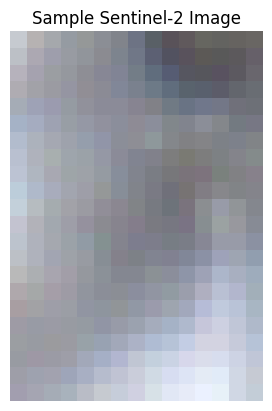

In [126]:
import rasterio
import matplotlib.pyplot as plt

path = "images/9521100585.0.tif"  # pick one id

with rasterio.open(path) as src:
    img = src.read()  # (bands, H, W)

rgb = img.transpose(1, 2, 0)
plt.imshow(rgb / rgb.max())
plt.title("Sample Sentinel-2 Image")
plt.axis("off")


In [219]:
data = data.reset_index(drop=True)
data["id"] = data.index.astype("int64")

In [220]:
image_data = data[["id", "lat", "long"]].copy()
image_data["image_path"] = image_data["id"].apply(lambda x: f"images/{x}.tif")


In [ ]:
import os


image_files = os.listdir("images")


image_ids = [f.split('.')[0] for f in image_files]  # e.g., '7977200945'


id_to_path = {int(float(fid)): f"images/{fid}.tif" for fid in image_ids}


image_data["image_path"] = image_data["id"].apply(lambda x: id_to_path.get(x, None))


image_data = image_data.dropna(subset=["image_path"]).reset_index(drop=True)


print(image_data.shape)
print(image_data["image_path"].iloc[:5])
print(os.path.exists(image_data["image_path"].iloc[0]))  # should be True




(4239, 4)
0    images/0.tif
1    images/1.tif
2    images/2.tif
3    images/3.tif
4    images/4.tif
Name: image_path, dtype: object
True


In [229]:
print(data.shape)
print(image_data.shape)

print(image_data.head())
print(os.path.exists(image_data.iloc[0]["image_path"]))


(16209, 17)
(4239, 4)
   id      lat     long    image_path
0   0  47.4362 -122.187  images/0.tif
1   1  47.4034 -122.187  images/1.tif
2   2  47.2704 -122.313  images/2.tif
3   3  47.5321 -122.073  images/3.tif
4   4  47.3715 -122.074  images/4.tif
True


In [230]:
class HouseImageDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")
        # Read image
        with rasterio.open(img_path) as src:
            img = src.read().transpose(1,2,0)  # HWC
        img = cv2.resize(img, (224,224))
        img = img / 10000.0  # normalize
        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)  # CHW
        return img

dataset = HouseImageDataset(image_data)
loader = DataLoader(dataset, batch_size=32, shuffle=False)


In [231]:
print(data.columns)
print(image_data.columns)


Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'grade', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'id'],
      dtype='object')
Index(['id', 'lat', 'long', 'image_path'], dtype='object')


In [232]:
print(image_data.head())
print(image_data["image_path"].isnull().sum())  # should be 0
print(os.path.exists(image_data.iloc[0]["image_path"]))  # should be True


   id      lat     long    image_path
0   0  47.4362 -122.187  images/0.tif
1   1  47.4034 -122.187  images/1.tif
2   2  47.2704 -122.313  images/2.tif
3   3  47.5321 -122.073  images/3.tif
4   4  47.3715 -122.074  images/4.tif
0
True


In [ ]:
import torch
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F




cnn = models.resnet18(pretrained=True)
cnn.fc = nn.Identity()  
cnn.eval()  

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn = cnn.to(device)


image_features = []

with torch.no_grad():
    for imgs in loader:
        imgs = imgs.to(device)
        feats = cnn(imgs)
        image_features.append(feats.cpu())

image_features = torch.cat(image_features, dim=0).numpy()

print("✅ Image features extracted")
print("Shape:", image_features.shape) 


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


✅ Image features extracted
Shape: (4239, 512)


In [ ]:
# Drop 'id' if present
X_tab = tabular_data.drop(columns=["id"]).values  
y_final = y_price[tabular_data.index].values     
print(X_tab.shape)
y_final.shape


(4239, 16)


(4239,)

In [ ]:
import numpy as np

X_final = np.hstack([X_tab, image_features]) 
print("Final feature matrix shape:", X_final.shape)



Final feature matrix shape: (4239, 528)


In [242]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R2 score:", r2_score(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
print("MSE:",mse)


R2 score: 0.6476156401586997
RMSE: 270587.42852769286
MSE: 73217556477.22928
